In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [2]:
exp_name = 'default_003'

gsnn_res = pd.read_csv(f'../../workflow_outputs/gsnn-mds/exp/{exp_name}/gsnn/stratified_results.csv')
nn_res = pd.read_csv(f'../../workflow_outputs/gsnn-mds/exp/{exp_name}/nn/stratified_results.csv')
res = gsnn_res.merge(nn_res, on='drug_combination', suffixes=('_gsnn', '_nn'))
res = res.assign(is_comb = [' + ' in x for x in res.drug_combination])

In [3]:
res[lambda x: x.drug_combination == 'overall'][['spearman_r_gsnn', 'spearman_r_nn']]

,spearman_r_gsnn,spearman_r_nn
142,0.700463,0.621398


In [4]:
res[lambda x: x.drug_combination == 'overall'][['r2_gsnn', 'r2_nn']]

,r2_gsnn,r2_nn
142,0.481815,0.383496


In [5]:
res[lambda x: x.drug_combination == 'overall'][['mse_gsnn', 'mse_nn']]

,mse_gsnn,mse_nn
142,0.408953,0.486546


In [6]:
# remove "overall"
res = res[res['drug_combination'] != 'overall']

# remove drugs that have less than 10 samples 
#res = res[res['n_samples_gsnn'] >= 10]

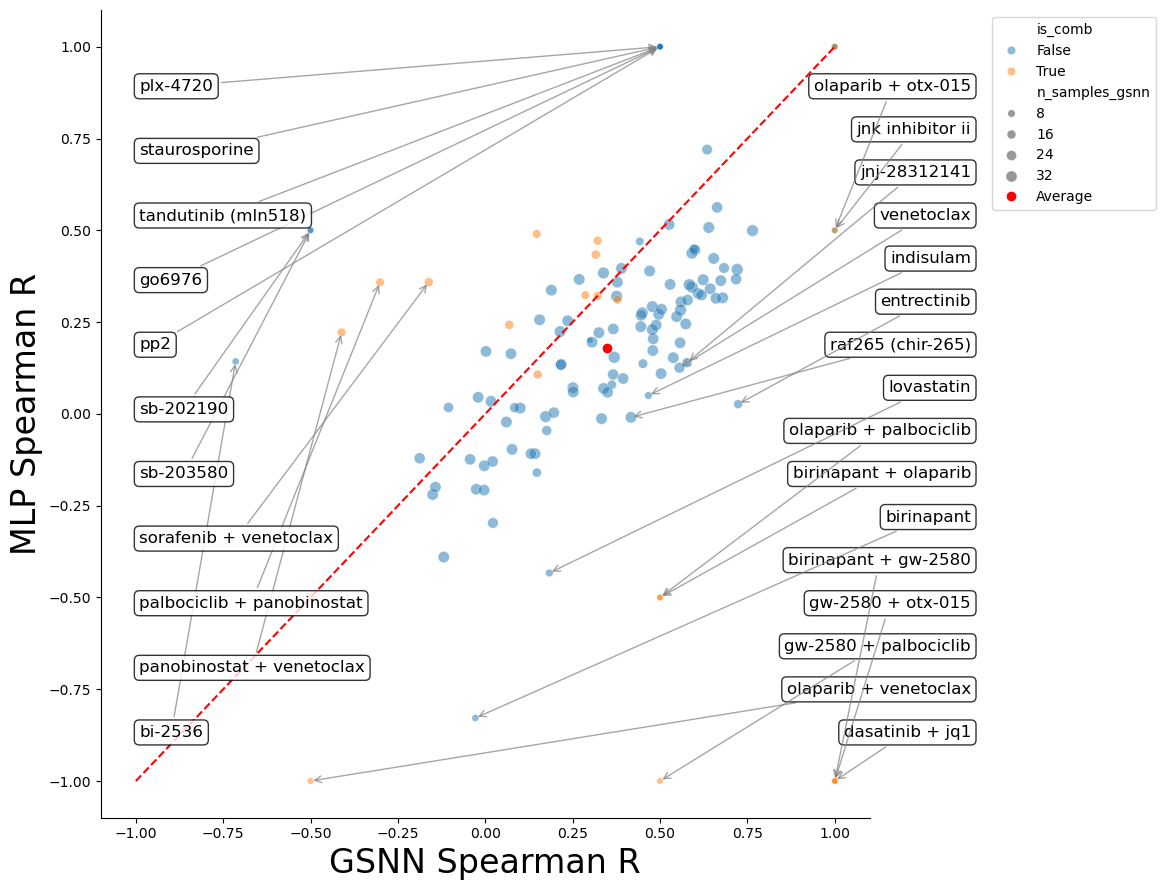

In [16]:
plt.figure(figsize=(12, 9)) 
sbn.scatterplot(data=res, x='spearman_r_gsnn', y='spearman_r_nn', alpha=0.5, hue='is_comb', size='n_samples_gsnn')
plt.plot([-1, 1], [-1, 1], 'r--')
plt.xlabel('GSNN Spearman R', fontsize=24)
plt.ylabel('MLP Spearman R', fontsize=24)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# label outliers (difference > 0.4)
outliers = res[abs(res['spearman_r_gsnn'] - res['spearman_r_nn']) > 0.4]

# Get plot limits for positioning
xlim = plt.xlim()
ylim = plt.ylim()

# Split outliers based on which side of diagonal they're on
# Left side: GSNN performs better (upper left triangle)
left_outliers = outliers[outliers['spearman_r_gsnn'] < outliers['spearman_r_nn']].sort_values('spearman_r_nn')
# Right side: NN performs better (lower right triangle)  
right_outliers = outliers[outliers['spearman_r_gsnn'] > outliers['spearman_r_nn']].sort_values('spearman_r_nn')

# Position labels on the left side
left_x = xlim[0] + (xlim[1] - xlim[0]) * 0.05  # 5% from left edge
for i, (idx, row) in enumerate(left_outliers.iterrows()):
    label_y = ylim[0] + (ylim[1] - ylim[0]) * (0.1 + 0.8 * i / max(1, len(left_outliers)-1))
    plt.annotate(f'{row["drug_combination"]}', 
                xy=(row['spearman_r_gsnn'], row['spearman_r_nn']),
                xytext=(left_x, label_y),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7),
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                fontsize=12)

# Position labels on the right side  
right_x = xlim[1] - (xlim[1] - xlim[0]) * 0.05 + 0.4 # 5% from right edge
for i, (idx, row) in enumerate(right_outliers.iterrows()):
    label_y = ylim[0] + (ylim[1] - ylim[0]) * (0.1 + 0.8 * i / max(1, len(right_outliers)-1))
    plt.annotate(f'{row["drug_combination"]}', 
                xy=(row['spearman_r_gsnn'], row['spearman_r_nn']),
                xytext=(right_x, label_y),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7),
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                fontsize=12,
                ha='right')

#  average  
plt.plot(res.spearman_r_gsnn.mean(), res.spearman_r_nn.mean(), 'o', color='red', label='Average')

# put legend outside the plot 
plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left')

plt.tight_layout() 
plt.show() 

In [8]:
res[lambda x: x.drug_combination == 'venetoclax']

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb
103,venetoclax,29,-0.527615,0.659199,0.86414,0.555665,29,-0.845492,0.219326,1.043957,0.125616,False


In [9]:
res[lambda x: x.drug_combination.str.startswith('azacitidine')]

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb


In [10]:
res[lambda x: x.n_samples_gsnn > 20].sort_values('spearman_r_gsnn', ascending=False).head(10)

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb
85,trametinib (gsk1120212),36,0.519906,0.732962,0.367036,0.764736,36,0.225455,0.525783,0.592145,0.499099,False
16,dasatinib,38,0.352623,0.690892,0.499732,0.720976,38,0.147709,0.396479,0.657912,0.393369,False
21,foretinib (xl880),32,0.238947,0.652025,0.592375,0.717742,32,0.109310,0.366345,0.693280,0.366935,False
102,lenvatinib,28,0.360881,0.697686,0.428099,0.683087,28,0.139553,0.397886,0.576350,0.397373,False
11,cabozantinib,34,0.245895,0.539754,0.452947,0.679450,34,-0.029384,0.320178,0.618291,0.316119,False
88,vargetef,33,0.336846,0.593735,0.340632,0.673797,33,0.078876,0.337558,0.473140,0.362968,False
44,mgcd-265,32,0.320942,0.591241,0.235830,0.663490,32,-0.060314,0.405812,0.368236,0.562317,False
82,tivozanib (av-951),33,0.335644,0.604607,0.459768,0.659814,33,0.023000,0.296315,0.676134,0.314699,False
75,selumetinib (azd6244),34,0.359188,0.607464,0.645188,0.653526,34,0.094158,0.412133,0.912029,0.423409,False
50,motesanib (amg-706),34,0.403840,0.672821,0.296500,0.643589,34,0.154995,0.394811,0.420263,0.340669,False


In [11]:
res[lambda x: x.n_samples_gsnn > 25].sort_values('r2_gsnn', ascending=False).head(25)

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb
85,trametinib (gsk1120212),36,0.519906,0.732962,0.367036,0.764736,36,0.225455,0.525783,0.592145,0.499099,False
9,bosutinib (ski-606),32,0.423386,0.672619,0.238051,0.608871,32,0.135845,0.415318,0.356760,0.328079,False
50,motesanib (amg-706),34,0.403840,0.672821,0.296500,0.643589,34,0.154995,0.394811,0.420263,0.340669,False
101,jq1,27,0.396892,0.687805,0.151037,0.634921,27,0.467538,0.687587,0.133345,0.719780,False
102,lenvatinib,28,0.360881,0.697686,0.428099,0.683087,28,0.139553,0.397886,0.576350,0.397373,False
75,selumetinib (azd6244),34,0.359188,0.607464,0.645188,0.653526,34,0.094158,0.412133,0.912029,0.423409,False
16,dasatinib,38,0.352623,0.690892,0.499732,0.720976,38,0.147709,0.396479,0.657912,0.393369,False
39,kw-2449,33,0.340744,0.609803,0.359474,0.547460,33,0.012834,0.312692,0.538274,0.264706,False
88,vargetef,33,0.336846,0.593735,0.340632,0.673797,33,0.078876,0.337558,0.473140,0.362968,False
82,tivozanib (av-951),33,0.335644,0.604607,0.459768,0.659814,33,0.023000,0.296315,0.676134,0.314699,False


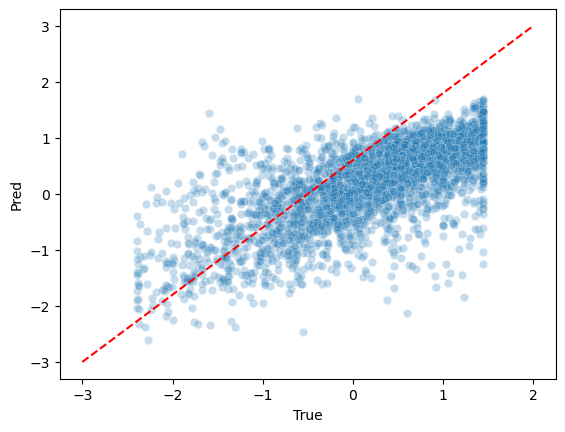

In [12]:
gsnn_preds = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/gsnn/predictions.csv') 
nn_preds = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/nn/predictions.csv') 

plt.figure() 
sbn.scatterplot(data=gsnn_preds, x='y_true', y='y_pred', alpha=0.25)
plt.plot([-3, 2], [-3, 3], 'r--')
plt.xlabel('True')
plt.ylabel('Pred')
plt.show() 

In [13]:
gsnn_preds.shape

(3503, 2)

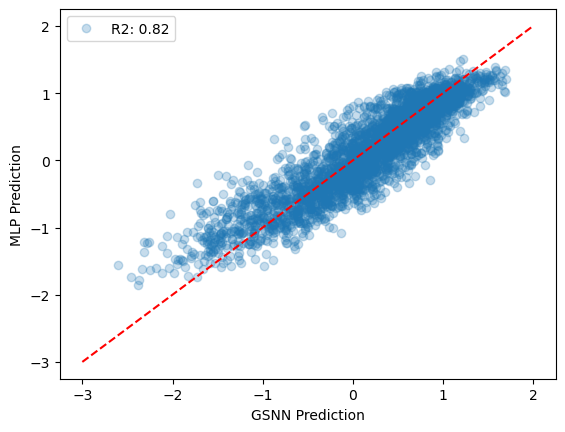

In [14]:
from sklearn.metrics import r2_score
r2 = r2_score(gsnn_preds.y_pred, nn_preds.y_pred)

plt.figure() 
plt.plot(gsnn_preds.y_pred, nn_preds.y_pred, 'o', alpha=0.25, label=f'R2: {r2:.2f}')
plt.plot([-3, 2], [-3, 2], 'r--')
plt.xlabel('GSNN Prediction')
plt.ylabel('MLP Prediction')
plt.legend()
plt.show() 

In [15]:
pred_mean = (gsnn_preds.y_pred + nn_preds.y_pred) / 2 

r_nn = np.corrcoef(nn_preds.y_pred, nn_preds.y_true)[0, 1]
r_gsnn = np.corrcoef(gsnn_preds.y_pred, gsnn_preds.y_true)[0, 1]
r_mean = np.corrcoef(pred_mean, gsnn_preds.y_true)[0, 1] 

print(f'NN R: {r_nn:.2f}, GSNN R: {r_gsnn:.2f}, Mean R: {r_mean:.2f}')

NN R: 0.70, GSNN R: 0.71, Mean R: 0.72
